# Ceng 484 HW2 Phase 2 / 300201026
**Paper:** *Analysis of Simple Data Imputation in Disease Dataset* (Anggraeny et al., ICST 2018)  
**Datasets:** Pima Indians Diabetes, Hepatitis, Breast Cancer Wisconsin

---

## 1. Main Gaps in the Original Paper

This notebook reproduces the paper and fixes its main methodology issues:

### Gap 1 - "Zero imputation is best" claim
- In medical features, many zeros are invalid (they mean missing).
- Zero-filling can create artificial patterns when we use FCM.
- We keep zero imputation only for comparison.

### Gap 2 - FCM + accuracy mismatch
- FCM is unsupervised clustering.
- Accuracy is a supervised metric.
- We evaluate with a supervised classifier (KNN).

### Gap 3 - Missing feature scaling
- Distance-based methods are scale-sensitive.
- We apply `StandardScaler` in the pipeline.

### Gap 4 - Limited imputation baseline
- The paper tests only simple univariate methods.
- We add `KNNImputer` as a multivariate baseline.

### Gap 5 - Limited silhouette analysis
- The paper shows silhouette plots only for zero imputation.
- We compare silhouette scores across all imputation strategies.

### 1. Imports and Reference Values

This cell imports libraries for:
- data handling (`pandas`, `numpy`)
- imputation (`SimpleImputer`, `KNNImputer`)
- classification (`KNeighborsClassifier`)
- clustering/silhouette analysis (`KMeans`, `silhouette_score`, `silhouette_samples`)

`paper_results` stores Table V accuracy values from the paper so we can compare our results directly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

# ── Paper reported accuracies (Table V) for comparison ───────────────────────
paper_results = {
    'Pima':          {'Zero': 65.0, 'Mean': 51.0, 'Median': 54.0, 'Random': 51.0, 'WDS': 43.0},
    'Hepatitis':     {'Zero': 87.0, 'Mean': 40.0, 'Median': 38.0, 'Random': 45.0, 'WDS': 50.0},
    'Breast Cancer': {'Zero': 76.0, 'Mean': 40.0, 'Median': 58.0, 'Random': 45.0, 'WDS': 42.0}
}

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Missingness Analysis

Before imputing, we first inspect where missing values are concentrated in each dataset.

For Pima, zeros in physiological columns are treated as missing (`NaN`) because they are not valid measurements.

In [2]:
# ── Load Pima Indians ─────────────────────────────────────────────────────────
url_pima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Class']
df_pima_raw = pd.read_csv(url_pima, names=pima_cols)

# Invalid-zero columns (cannot be 0 biologically)
invalid_zero_cols_pima = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_pima = df_pima_raw.copy()
df_pima[invalid_zero_cols_pima] = df_pima[invalid_zero_cols_pima].replace(0, np.nan)

# ── Load Hepatitis ────────────────────────────────────────────────────────────
df_hep_raw = pd.read_csv('hepatitis.csv')
df_hep = df_hep_raw.rename(columns={
    'class': 'Class', 'age': 'Age', 'sex': 'Sex', 'steroid': 'Steroid',
    'antivirals': 'Antivirals', 'fatigue': 'Fatigue', 'malaise': 'Malaise',
    'anorexia': 'Anorexia', 'liver_big': 'LiverBig', 'liver_firm': 'LiverFirm',
    'spleen_palpable': 'SpleenPalpable', 'spiders': 'Spiders', 'ascites': 'Ascites',
    'varices': 'Varices', 'bilirubin': 'Bilirubin', 'alk_phosphate': 'AlkPhosphate',
    'sgot': 'SGOT', 'albumin': 'Albumin', 'protime': 'Protime', 'histology': 'Histology'
})
binary_map = {'true': 1, 'false': 0, 'yes': 1, 'no': 0,
              'male': 1, 'female': 0, 'live': 1, 'die': 0}
for col in df_hep.columns:
    if df_hep[col].dtype == object:
        df_hep[col] = df_hep[col].astype(str).str.strip().str.lower().replace(binary_map)
    df_hep[col] = pd.to_numeric(df_hep[col], errors='coerce')
df_hep = df_hep.dropna(subset=['Class'])

# ── Load Breast Cancer Wisconsin ──────────────────────────────────────────────
# Correct UCI file: 699 instances, 10 features + 1 class (2=benign, 4=malignant)
# bare_nucleoli has 16 rows encoded as '?' -> treated as NaN
df_bc_raw = pd.read_csv('breast-cancer-wisconsin.csv', na_values='?')
df_bc = df_bc_raw.rename(columns={
    'id': 'ID',
    'clump_thickness': 'ClumpThickness',
    'size_uniformity': 'SizeUniformity',
    'shape_uniformity': 'ShapeUniformity',
    'marginal_adhesion': 'MarginalAdhesion',
    'epithelial_size': 'EpithelialSize',
    'bare_nucleoli': 'BareNuclei',
    'bland_chromatin': 'BlandChromatin',
    'normal_nucleoli': 'NormalNucleoli',
    'mitoses': 'Mitoses',
    'class': 'Class'
})
# Paper: class 2 = benign -> 0, class 4 = malignant -> 1
df_bc['Class'] = df_bc['Class'].map({2: 0, 4: 1})
if 'ID' in df_bc.columns:
    df_bc = df_bc.drop('ID', axis=1)
for col in df_bc.columns:
    if df_bc[col].dtype == object:
        df_bc[col] = pd.to_numeric(df_bc[col], errors='coerce')

print(f'Pima:          {df_pima.shape[0]} rows, {df_pima.shape[1]} columns')
print(f'Hepatitis:     {df_hep.shape[0]} rows, {df_hep.shape[1]} columns')
print(f'Breast Cancer: {df_bc.shape[0]} rows, {df_bc.shape[1]} columns')


Pima:          768 rows, 9 columns
Hepatitis:     155 rows, 20 columns
Breast Cancer: 699 rows, 10 columns


This visualization does two things:
1. Computes missing-value percentages per feature.
2. Plots them for all three datasets.

Goal: identify which columns are most sensitive to imputation choice.

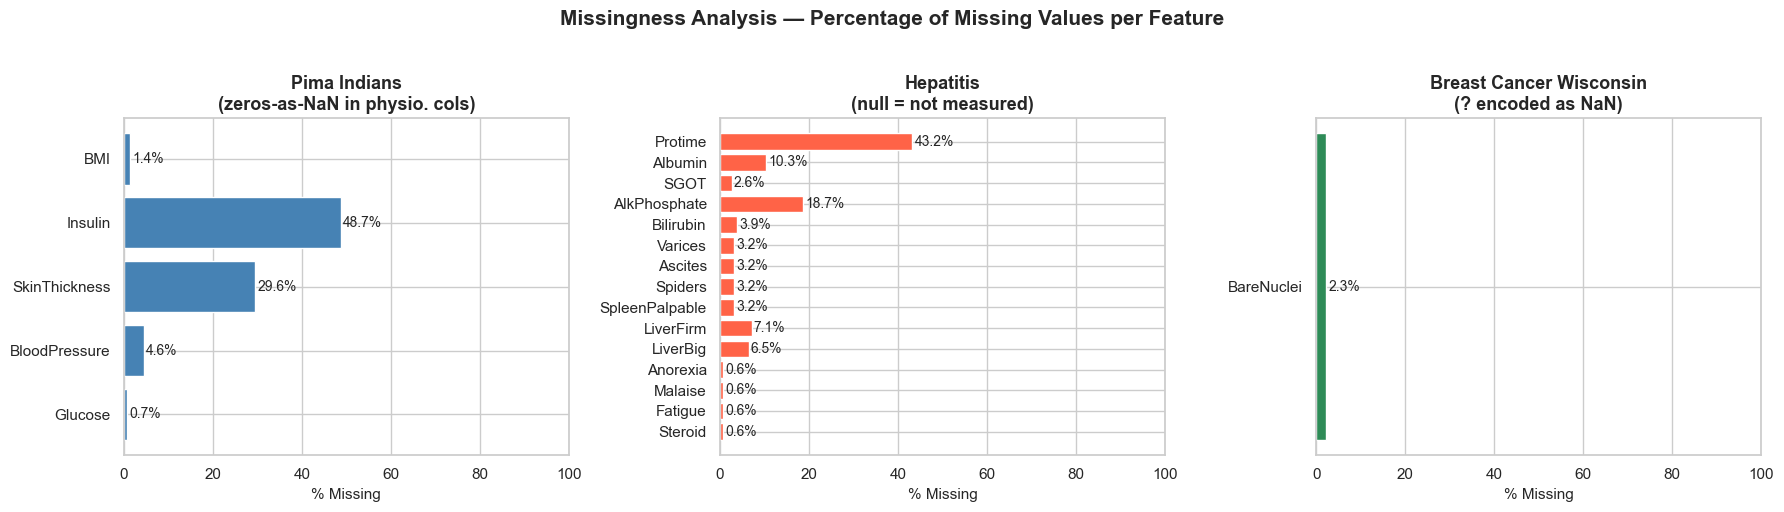


=== Missingness Summary ===

Pima Indians
(zeros-as-NaN in physio. cols):


,Feature,Missing,Missing_%
0,Glucose,5,0.7
1,BloodPressure,35,4.6
2,SkinThickness,227,29.6
3,Insulin,374,48.7
4,BMI,11,1.4



Hepatitis
(null = not measured):


,Feature,Missing,Missing_%
0,Steroid,1,0.6
1,Fatigue,1,0.6
2,Malaise,1,0.6
3,Anorexia,1,0.6
4,LiverBig,10,6.5
5,LiverFirm,11,7.1
6,SpleenPalpable,5,3.2
7,Spiders,5,3.2
8,Ascites,5,3.2
9,Varices,5,3.2



Breast Cancer Wisconsin
(? encoded as NaN):


,Feature,Missing,Missing_%
0,BareNuclei,16,2.3


In [3]:
def missingness_summary(df, name):
    """Return a DataFrame with absolute and percentage missing counts per column."""
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    return pd.DataFrame({'Feature': miss.index, 'Missing': miss.values,
                         'Missing_%': pct.values, 'Dataset': name}).query('Missing > 0')

miss_pima = missingness_summary(df_pima, 'Pima Indians')
miss_hep  = missingness_summary(df_hep,  'Hepatitis')
miss_bc   = missingness_summary(df_bc,   'Breast Cancer')

# ── Plot: side-by-side missingness bar charts ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets_miss = [
    (miss_pima, 'Pima Indians\n(zeros-as-NaN in physio. cols)', 'steelblue'),
    (miss_hep,  'Hepatitis\n(null = not measured)',              'tomato'),
    (miss_bc,   'Breast Cancer Wisconsin\n(? encoded as NaN)',   'seagreen'),
]
for ax, (miss_df, title, colour) in zip(axes, datasets_miss):
    if miss_df.empty:
        ax.text(0.5, 0.5, 'No missing values found', ha='center', va='center',
                transform=ax.transAxes, fontsize=13)
    else:
        bars = ax.barh(miss_df['Feature'], miss_df['Missing_%'], color=colour, edgecolor='white')
        for bar, val in zip(bars, miss_df['Missing_%']):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', va='center', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('% Missing', fontsize=11)
    ax.set_xlim(0, 100)

fig.suptitle('Missingness Analysis — Percentage of Missing Values per Feature',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== Missingness Summary ===' )
for miss_df, name, _ in datasets_miss:
    if not miss_df.empty:
        print(f'\n{name}:')
        display(miss_df[['Feature', 'Missing', 'Missing_%']].reset_index(drop=True).round(1))

---
## 3. Distribution Analysis: Effect of Imputation

This cell compares feature distributions after different imputations on Pima:
- Original (rows with NaN removed)
- Mean
- Median
- KNN

Why this matters:
- Mean/median often create a spike at one value.
- KNNImputation uses nearby samples, so distributions are usually smoother and more realistic.

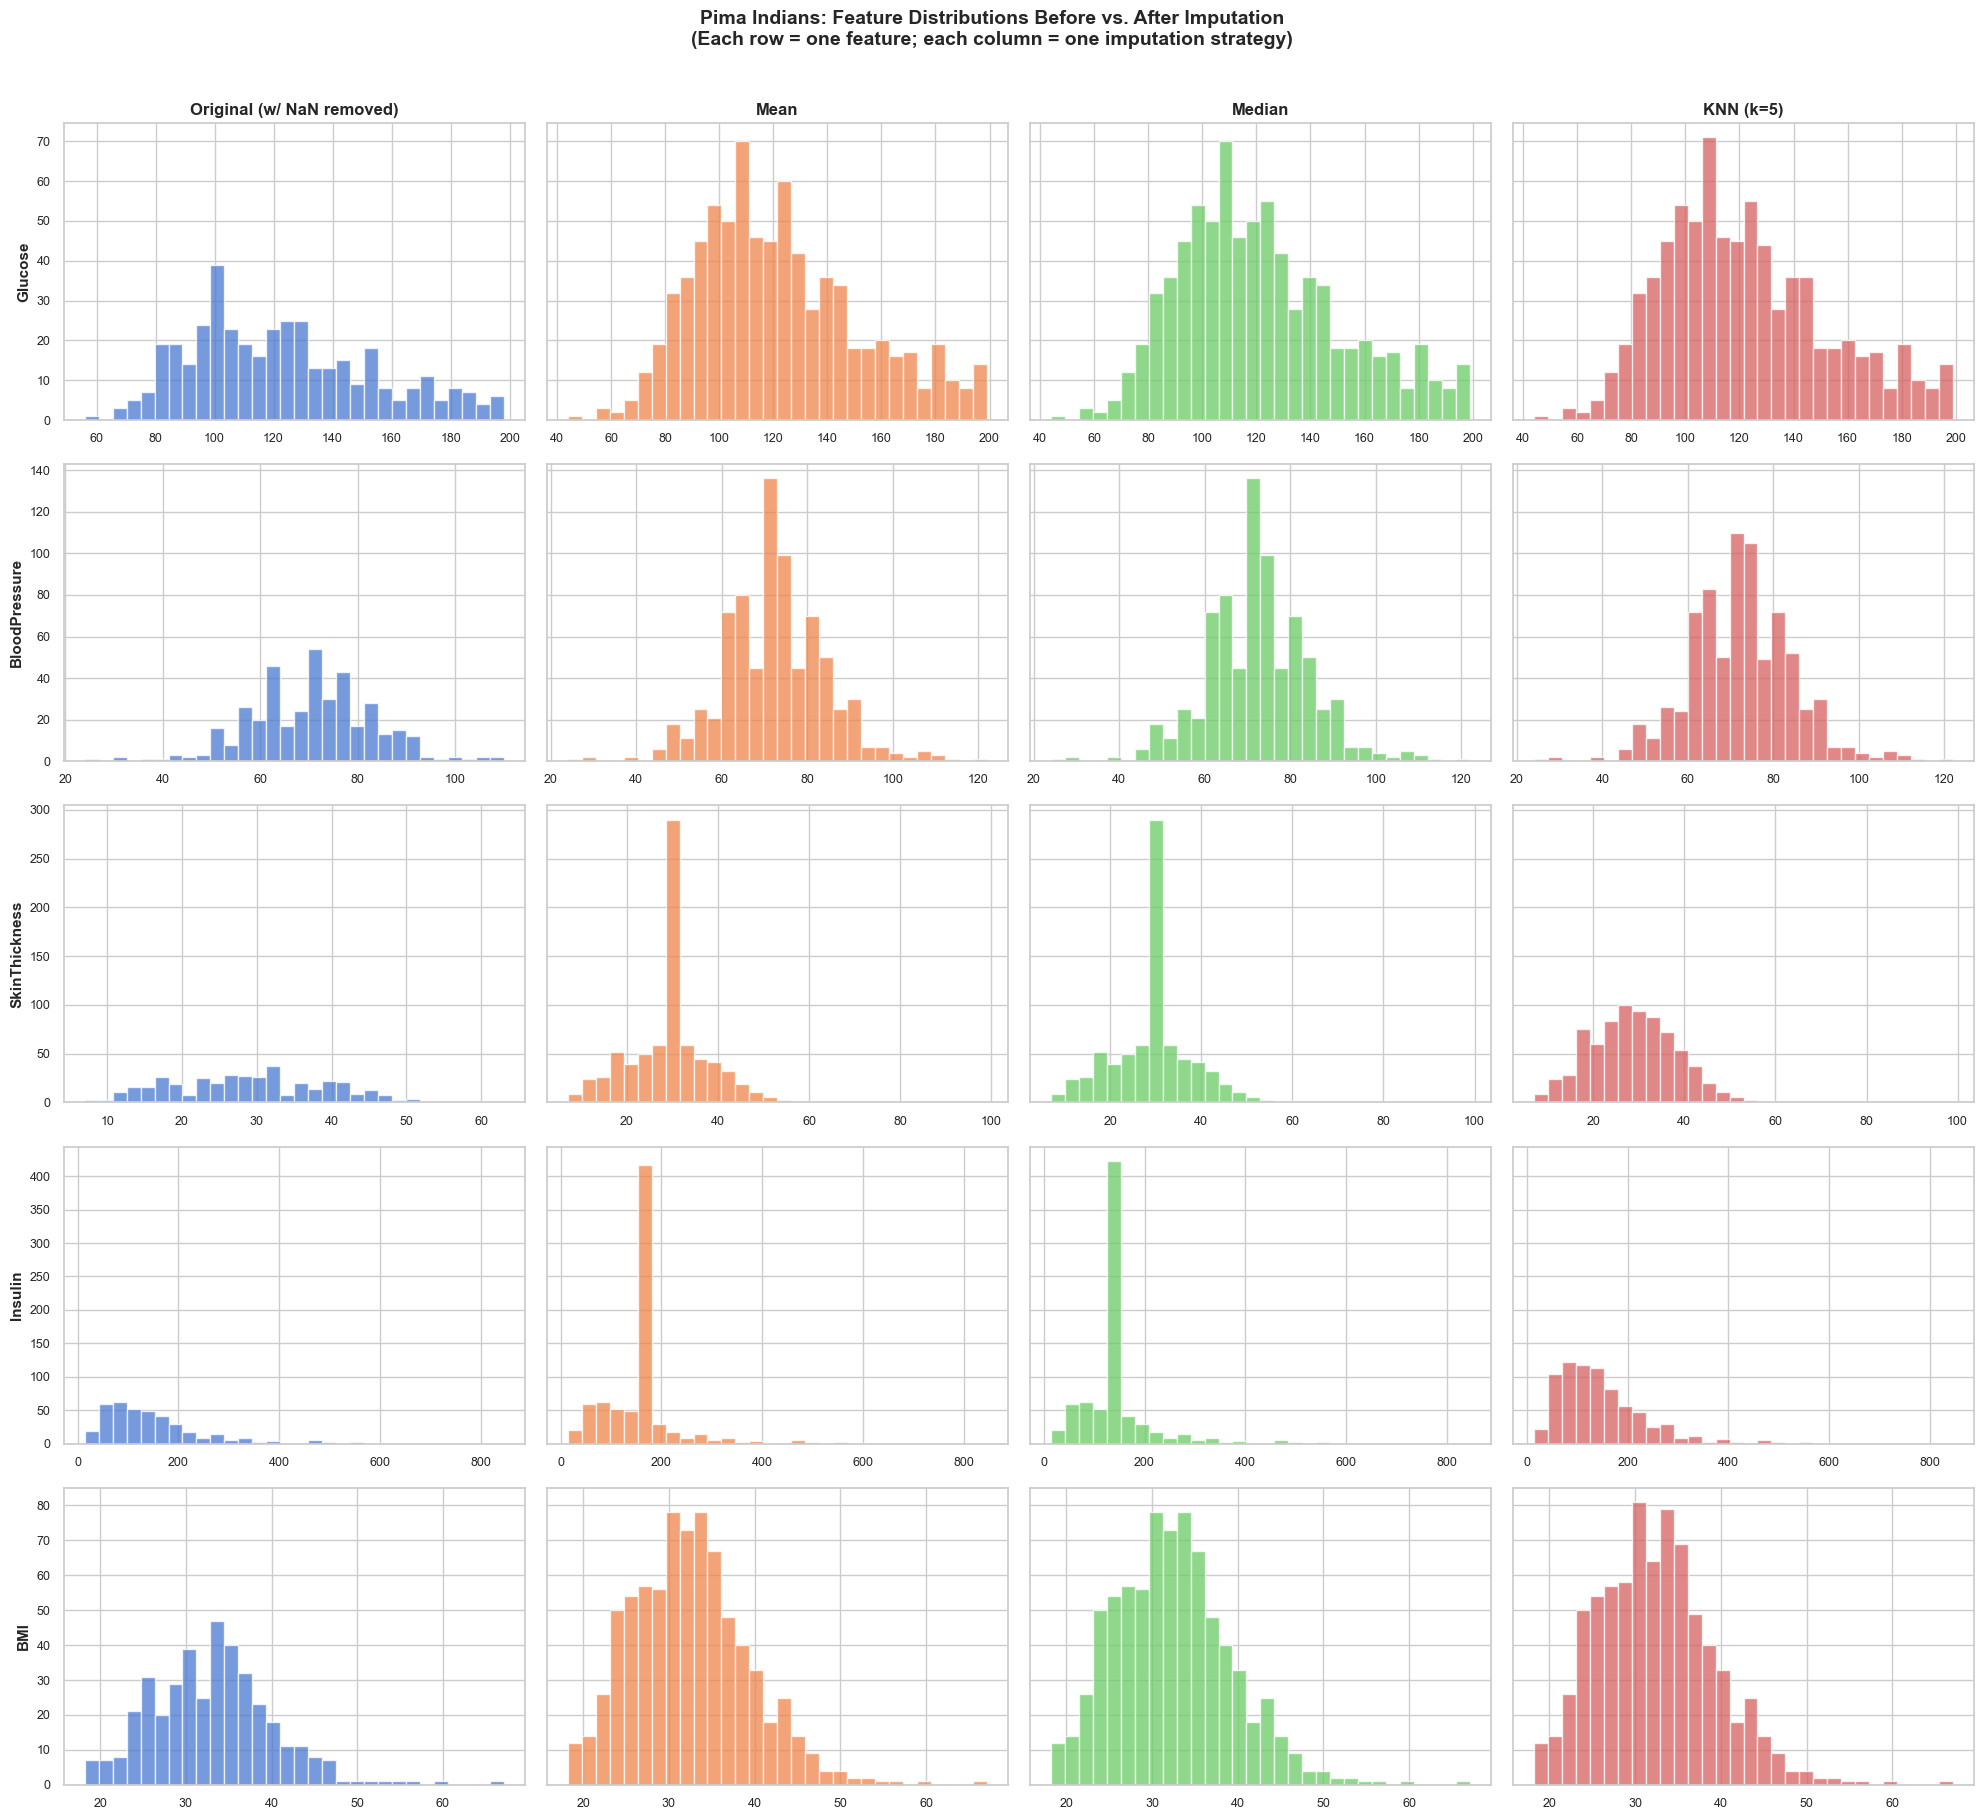


Observation: Mean/Median imputation creates an artificial spike at a single value, while KNN Imputation preserves a smoother, more realistic distribution.


In [4]:
# Focus on the Pima dataset — it has the richest missingness story
focus_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

imputers = {
    'Original (w/ NaN removed)': None,        # baseline: just drop NaNs
    'Mean':                       SimpleImputer(strategy='mean'),
    'Median':                     SimpleImputer(strategy='median'),
    'KNN (k=5)':                  KNNImputer(n_neighbors=5),
}

fig, axes = plt.subplots(len(focus_cols), len(imputers), figsize=(20, 18), sharey='row')
colours = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']

X_feat = df_pima[focus_cols]

for col_idx, (imp_name, imputer) in enumerate(imputers.items()):
    if imputer is None:
        X_plot = X_feat.dropna()
    else:
        X_plot = pd.DataFrame(imputer.fit_transform(X_feat), columns=focus_cols)

    for row_idx, feat in enumerate(focus_cols):
        ax = axes[row_idx][col_idx]
        ax.hist(X_plot[feat].dropna(), bins=30, color=colours[col_idx],
                alpha=0.75, edgecolor='white')
        if row_idx == 0:
            ax.set_title(imp_name, fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(feat, fontsize=11, fontweight='bold')
        ax.tick_params(labelsize=9)

fig.suptitle('Pima Indians: Feature Distributions Before vs. After Imputation\n'
             '(Each row = one feature; each column = one imputation strategy)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nObservation: Mean/Median imputation creates an artificial spike at a single value,'
      ' while KNN Imputation preserves a smoother, more realistic distribution.')

### 4. Classification Accuracy on Three Datasets

#### Why KNN classifier instead of FCM?

Paper issue: FCM is unsupervised clustering, but accuracy is a supervised metric.
So we evaluate imputation quality with a supervised model (KNN classifier).

---

This section tests these strategies under the same train/test setting:
- Zero (`SimpleImputer(fill_value=0)`)
- Mean (`SimpleImputer(mean)`)
- Median (`SimpleImputer(median)`)
- Random (custom `RandomImputer`)
- KNN Imputer (`KNNImputer`)
- WDS (`dropna`)

Paper issue: imputation can use information from the full dataset, which leaks test data statistics into preprocessing.
Our fix: fit each imputer on train only, then apply `transform` to test.

In [5]:
class RandomImputer:
    """Imputes missing values by sampling uniformly from observed values
    in the same column (fitted on training data only — no leakage).
    Mirrors the random imputation strategy in the paper (Table V).
    """
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.observed_values_ = {}

    def fit(self, X):
        X = np.array(X, dtype=float)
        for col in range(X.shape[1]):
            self.observed_values_[col] = X[:, col][~np.isnan(X[:, col])]
        return self

    def transform(self, X):
        rng = np.random.default_rng(self.random_state)
        X = np.array(X, dtype=float).copy()
        for col in range(X.shape[1]):
            mask = np.isnan(X[:, col])
            if mask.any() and len(self.observed_values_[col]) > 0:
                X[mask, col] = rng.choice(self.observed_values_[col], size=mask.sum())
        return X

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def evaluate_imputations(dataset_name, df, target_col):
    """
    Evaluate imputation strategies with a KNN classifier.
    Prevents data leakage: imputer is fit on train set only.
    Returns a DataFrame of results.
    """
    results = []

    # ── Whole Data Strategy (WDS) ─────────────────────────────────────────────
    df_wds = df.dropna()
    if len(df_wds) >= 20:
        X, y = df_wds.drop(target_col, axis=1), df_wds[target_col]
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
        pipe = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=5))])
        pipe.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, pipe.predict(X_te)) * 100
        results.append({'Dataset': dataset_name, 'Strategy': 'WDS (Drop NaN)',
                         'Our Acc (%)': acc,
                         'Paper Acc (%)': paper_results[dataset_name]['WDS'],
                         'N (train)': len(y_tr)})

    # ── Imputation strategies (matching paper Table V) ────────────────────────
    X_full = df.drop(target_col, axis=1)
    y_full = df[target_col]
    X_tr_b, X_te_b, y_tr, y_te = train_test_split(
        X_full, y_full, test_size=0.3, random_state=RANDOM_STATE, stratify=y_full)

    strategies = {
        'Zero Imputation':      SimpleImputer(strategy='constant', fill_value=0),
        'Mean Imputation':      SimpleImputer(strategy='mean'),
        'Median Imputation':    SimpleImputer(strategy='median'),
        'Random Imputation':    RandomImputer(random_state=RANDOM_STATE),
        'KNN Imputation (k=5)': KNNImputer(n_neighbors=5),
    }


    for name, imputer in strategies.items():
        X_tr_imp = imputer.fit_transform(X_tr_b)
        X_te_imp = imputer.transform(X_te_b)   # transform only — no leakage

        pipe = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=5))])
        pipe.fit(X_tr_imp, y_tr)
        acc = accuracy_score(y_te, pipe.predict(X_te_imp)) * 100

        paper_key = name.split()[0]   # 'Zero' / 'Mean' / 'Median' / 'Random'
        paper_acc = paper_results[dataset_name].get(paper_key, 'N/A')

        results.append({'Dataset': dataset_name, 'Strategy': name,
                         'Our Acc (%)': acc, 'Paper Acc (%)': paper_acc,
                         'N (train)': len(y_tr)})

    return pd.DataFrame(results)


# ── Run for all three datasets ────────────────────────────────────────────────
res_pima = evaluate_imputations('Pima',          df_pima, 'Class')
res_hep  = evaluate_imputations('Hepatitis',     df_hep,  'Class')
res_bc   = evaluate_imputations('Breast Cancer', df_bc,   'Class')

all_results = pd.concat([res_pima, res_hep, res_bc], ignore_index=True)

print('=== Pima Indians ===')
display(res_pima[['Strategy', 'Our Acc (%)', 'Paper Acc (%)', 'N (train)']].round(2))

print('\n=== Hepatitis ===')
display(res_hep[['Strategy', 'Our Acc (%)', 'Paper Acc (%)', 'N (train)']].round(2))

print('\n=== Breast Cancer Wisconsin ===')
display(res_bc[['Strategy', 'Our Acc (%)', 'Paper Acc (%)', 'N (train)']].round(2))


=== Pima Indians ===


,Strategy,Our Acc (%),Paper Acc (%),N (train)
0,WDS (Drop NaN),77.97,43.0,274
1,Zero Imputation,71.43,65.0,537
2,Mean Imputation,74.03,51.0,537
3,Median Imputation,74.46,54.0,537
4,Random Imputation,73.16,51.0,537
5,KNN Imputation (k=5),73.59,N/A,537



=== Hepatitis ===


,Strategy,Our Acc (%),Paper Acc (%),N (train)
0,WDS (Drop NaN),83.33,50.0,56
1,Zero Imputation,85.11,87.0,108
2,Mean Imputation,87.23,40.0,108
3,Median Imputation,87.23,38.0,108
4,Random Imputation,82.98,45.0,108
5,KNN Imputation (k=5),89.36,N/A,108



=== Breast Cancer Wisconsin ===


,Strategy,Our Acc (%),Paper Acc (%),N (train)
0,WDS (Drop NaN),95.61,42.0,478
1,Zero Imputation,95.24,76.0,489
2,Mean Imputation,95.24,40.0,489
3,Median Imputation,95.24,58.0,489
4,Random Imputation,95.24,45.0,489
5,KNN Imputation (k=5),95.24,N/A,489


Figure in the below will show comparesion our classifier accuracy with paper-reported values:
- Bars: our KNN classifier accuracy
- Black diamonds: paper FCM accuracy

It provides a direct, strategy-by-strategy visual comparison for each dataset.

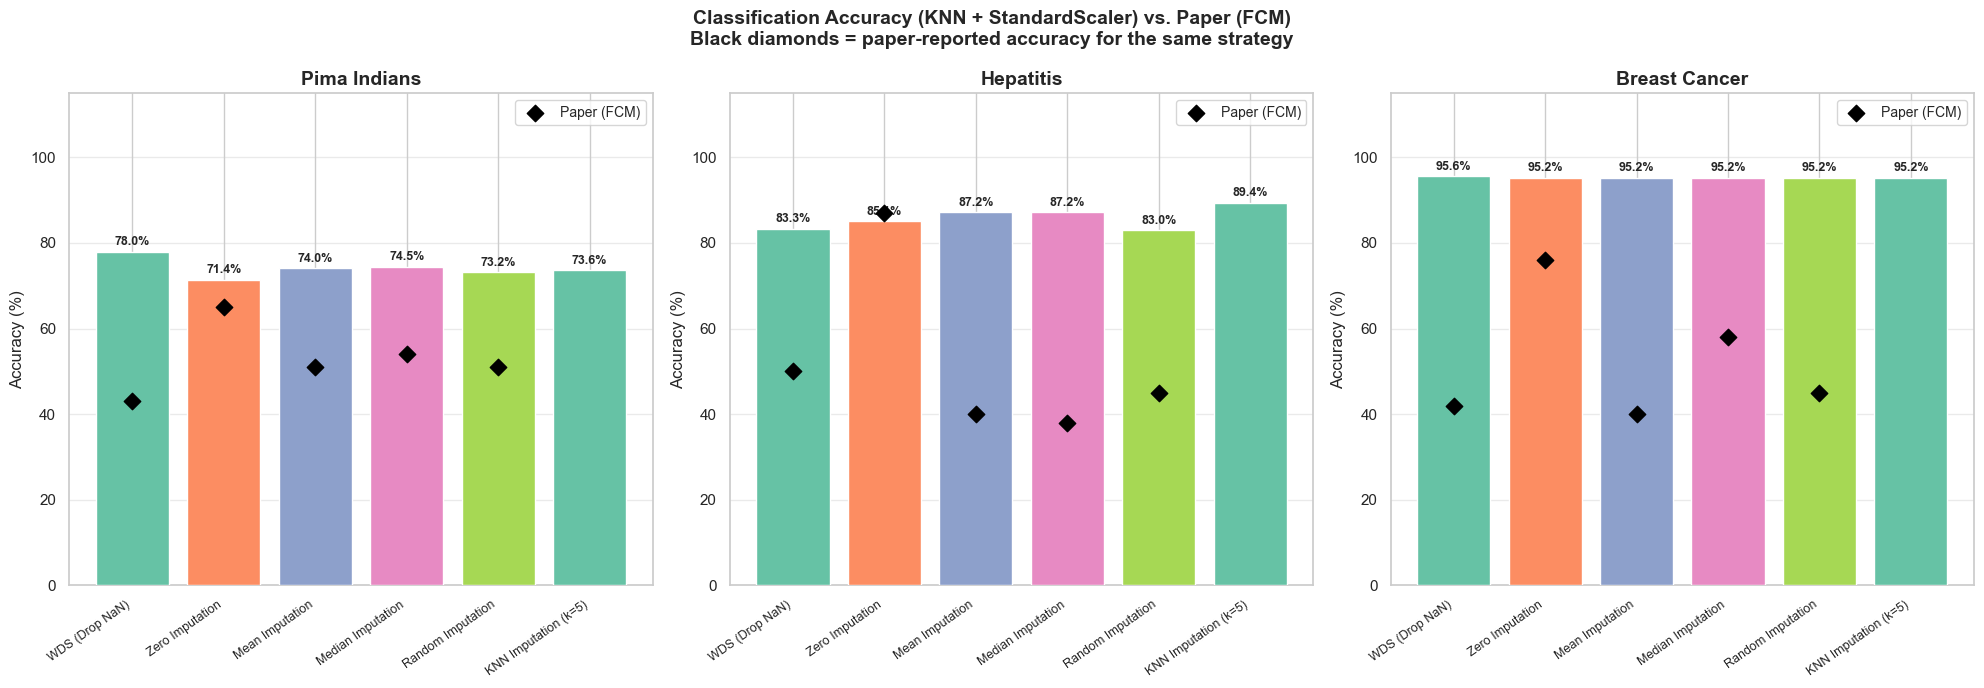

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
palette = sns.color_palette('Set2', n_colors=5)

for ax, (name, res_df) in zip(axes, [('Pima Indians', res_pima),
                                       ('Hepatitis',     res_hep),
                                       ('Breast Cancer', res_bc)]):
    bars = ax.bar(res_df['Strategy'], res_df['Our Acc (%)'],
                  color=palette, edgecolor='white', zorder=3)

    # Overlay paper accuracy as a scatter/line for easy comparison
    paper_vals = [v if isinstance(v, float) else None for v in res_df['Paper Acc (%)']]
    valid_x = [i for i, v in enumerate(paper_vals) if v is not None]
    valid_y = [v for v in paper_vals if v is not None]
    ax.scatter(valid_x, valid_y, marker='D', color='black', zorder=5,
               s=70, label='Paper (FCM)')

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_ylim(0, 115)
    ax.set_xticklabels(res_df['Strategy'], rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.4, zorder=0)

fig.suptitle('Classification Accuracy (KNN + StandardScaler) vs. Paper (FCM)\n'
             'Black diamonds = paper-reported accuracy for the same strategy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Why are our accuracies much higher than the paper?

Main reasons:
1. We use a supervised classifier (KNN), not unsupervised FCM, for accuracy evaluation.
2. We apply `StandardScaler` for distance-based methods.
3. We prevent leakage by fitting imputers on train data only.

So the improvement comes from better evaluation design, not from a single "magic" imputation method.

---
## 5. Silhouette Analysis

Silhouette analysis shows how well samples are separated into clusters after imputation.
It measures both cluster compactness (samples close to their own cluster) and separation (far from other clusters).

Why we use plots here:
- You can see the full distribution of sample-level silhouette values, not only one mean score.
- Negative and near-zero regions are visible, so weak or mixed clusters are easy to detect.
- It makes method-to-method comparison (Zero, Mean, Median, KNN) more interpretable than a single number alone.

Silhouette score range:
- close to +1: well-separated clusters
- around 0: overlapping clusters
- below 0: likely misassigned samples

In [7]:
def make_silhouette_plot(ax, X_scaled, labels, title, cmap='RdYlGn'):
    """Silhouette plot — horizontal-bar style matching paper Figs 2-4."""
    n_clusters = len(np.unique(labels))
    sample_sil = silhouette_samples(X_scaled, labels)
    mean_sil   = silhouette_score(X_scaled, labels)

    y_lower = 10
    colours = cm.get_cmap(cmap)(np.linspace(0.2, 0.8, n_clusters))

    for idx, (cluster, colour) in enumerate(zip(np.unique(labels), colours)):
        sil_k  = np.sort(sample_sil[labels == cluster])
        size_k = sil_k.shape[0]
        y_upper = y_lower + size_k
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                         facecolor=colour, alpha=0.8, edgecolor='none')
        ax.text(-0.08, y_lower + 0.5 * size_k, str(cluster), fontsize=10)
        y_lower = y_upper + 10

    ax.axvline(x=mean_sil, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Silhouette Value', fontsize=10)
    ax.set_ylabel('Cluster', fontsize=10)
    ax.set_yticks([])
    ax.set_xlim(-0.6, 1.0)
    ax.set_title(f'{title}\n(mean = {mean_sil:.3f})', fontsize=11, fontweight='bold')
    return mean_sil


def run_fcm(X_scaled, c=2, m=2, max_iter=100, eps=1e-5, random_state=42):
    """Fuzzy C-Means — implements paper Section II-D. Returns hard cluster labels."""
    rng = np.random.default_rng(random_state)
    n, d = X_scaled.shape

    U = rng.random((n, c))
    U = U / U.sum(axis=1, keepdims=True)

    P_prev = 0.0
    for _ in range(max_iter):
        Um = U ** m
        V  = (Um.T @ X_scaled) / Um.sum(axis=0)[:, None]   # (c, d)

        # Objective function
        P = 0.0
        for ci in range(c):
            dist2 = ((X_scaled - V[ci]) ** 2).sum(axis=1)
            P += (dist2 * Um[:, ci]).sum()

        # Update membership matrix
        new_U = np.zeros((n, c))
        for ci in range(c):
            dist_ci = ((X_scaled - V[ci]) ** 2).sum(axis=1) + 1e-10
            for cj in range(c):
                dist_cj = ((X_scaled - V[cj]) ** 2).sum(axis=1) + 1e-10
                new_U[:, ci] += (dist_ci / dist_cj) ** (1.0 / (m - 1))
            new_U[:, ci] = 1.0 / new_U[:, ci]
        U = new_U

        if abs(P - P_prev) < eps:
            break
        P_prev = P

    return U.argmax(axis=1)


def compute_silhouette_scores(df, target_col, n_clusters=2):
    """
    For each imputation strategy run KMeans AND FCM.
    Returns Ground Truth, KMeans, and FCM labels + silhouette scores.
    """
    strategies = {
        'Zero Imputation':      SimpleImputer(strategy='constant', fill_value=0),
        'Mean Imputation':      SimpleImputer(strategy='mean'),
        'Median Imputation':    SimpleImputer(strategy='median'),
        'KNN Imputation (k=5)': KNNImputer(n_neighbors=5),
    }

    X_raw  = df.drop(target_col, axis=1).values
    y_true = df[target_col].values.astype(int)

    out = {}
    for name, imp in strategies.items():
        X_imp    = imp.fit_transform(X_raw)
        X_scaled = StandardScaler().fit_transform(X_imp)

        km_lbl  = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE,
                         n_init=10).fit_predict(X_scaled)
        fcm_lbl = run_fcm(X_scaled, c=n_clusters, random_state=RANDOM_STATE)

        out[name] = {
            'score_km':   silhouette_score(X_scaled, km_lbl),
            'score_fcm':  silhouette_score(X_scaled, fcm_lbl),
            'labels_km':  km_lbl,
            'labels_fcm': fcm_lbl,
            'X_scaled':   X_scaled,
            'y_true':     y_true,
        }
    return out


print('Helper functions defined.')


Helper functions defined.


### Pima Silhouette Plots

Rows in the figure:
- Row 1: silhouette using ground-truth labels
- Row 2: silhouette using KMeans labels
- Row 3: silhouette using FCM labels

This lets us compare natural class separation vs clustering behavior under each imputation strategy.

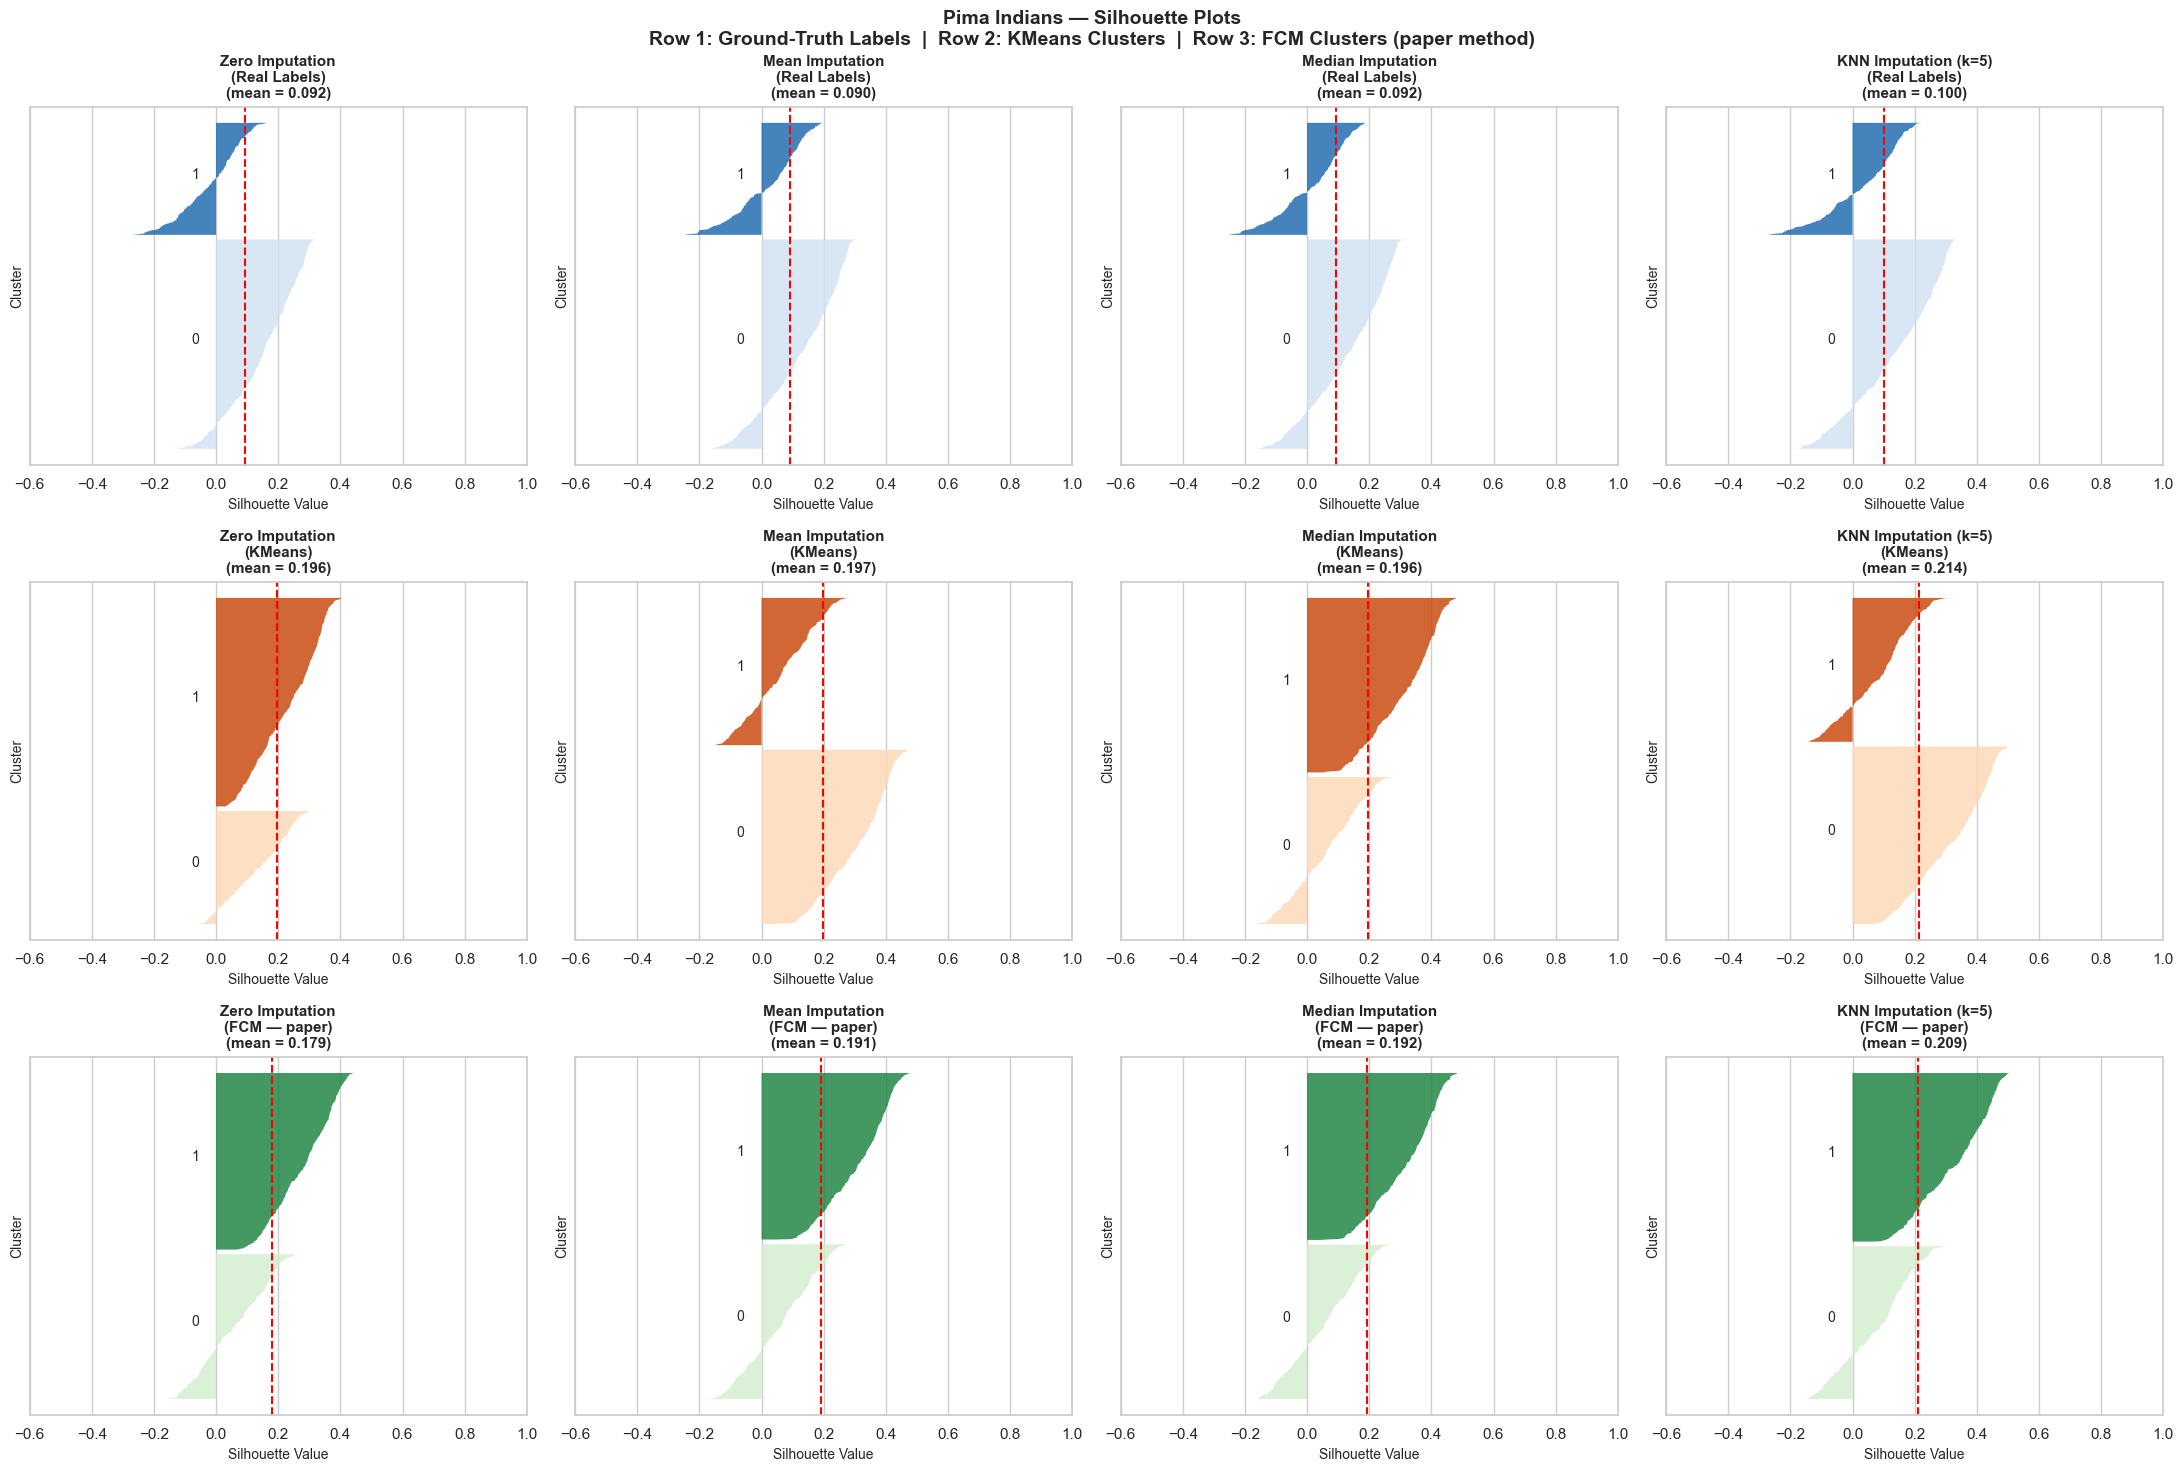


Pima Indians — Silhouette Scores by Strategy:


,Strategy,KMeans Score,FCM Score
0,Zero Imputation,0.1960,0.1794
1,Mean Imputation,0.1965,0.1913
2,Median Imputation,0.1963,0.1918
3,KNN Imputation (k=5),0.2141,0.2094


In [8]:
# ── 5.1  Pima Indians — Silhouette Plots (replicating paper Fig. 2) ───────────
pima_sil = compute_silhouette_scores(df_pima, 'Class', n_clusters=2)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Pima Indians — Silhouette Plots\n'
             'Row 1: Ground-Truth Labels  |  Row 2: KMeans Clusters  |  Row 3: FCM Clusters (paper method)',
             fontsize=14, fontweight='bold')

for col_idx, (name, data) in enumerate(pima_sil.items()):
    make_silhouette_plot(axes[0][col_idx], data['X_scaled'], data['y_true'],
                         f'{name}\n(Real Labels)', cmap='Blues')
    make_silhouette_plot(axes[1][col_idx], data['X_scaled'], data['labels_km'],
                         f'{name}\n(KMeans)', cmap='Oranges')
    make_silhouette_plot(axes[2][col_idx], data['X_scaled'], data['labels_fcm'],
                         f'{name}\n(FCM — paper)', cmap='Greens')

plt.tight_layout()
plt.show()

print('\nPima Indians — Silhouette Scores by Strategy:')
sil_df_pima = pd.DataFrame([
    {'Strategy': k, 'KMeans Score': v['score_km'], 'FCM Score': v['score_fcm']}
    for k, v in pima_sil.items()
])
display(sil_df_pima.round(4))


### Hepatitis Silhouette Plots

Same layout as Pima: real labels, KMeans labels, and FCM labels.

Purpose: compare cluster quality across imputations on a smaller, noisier medical dataset.

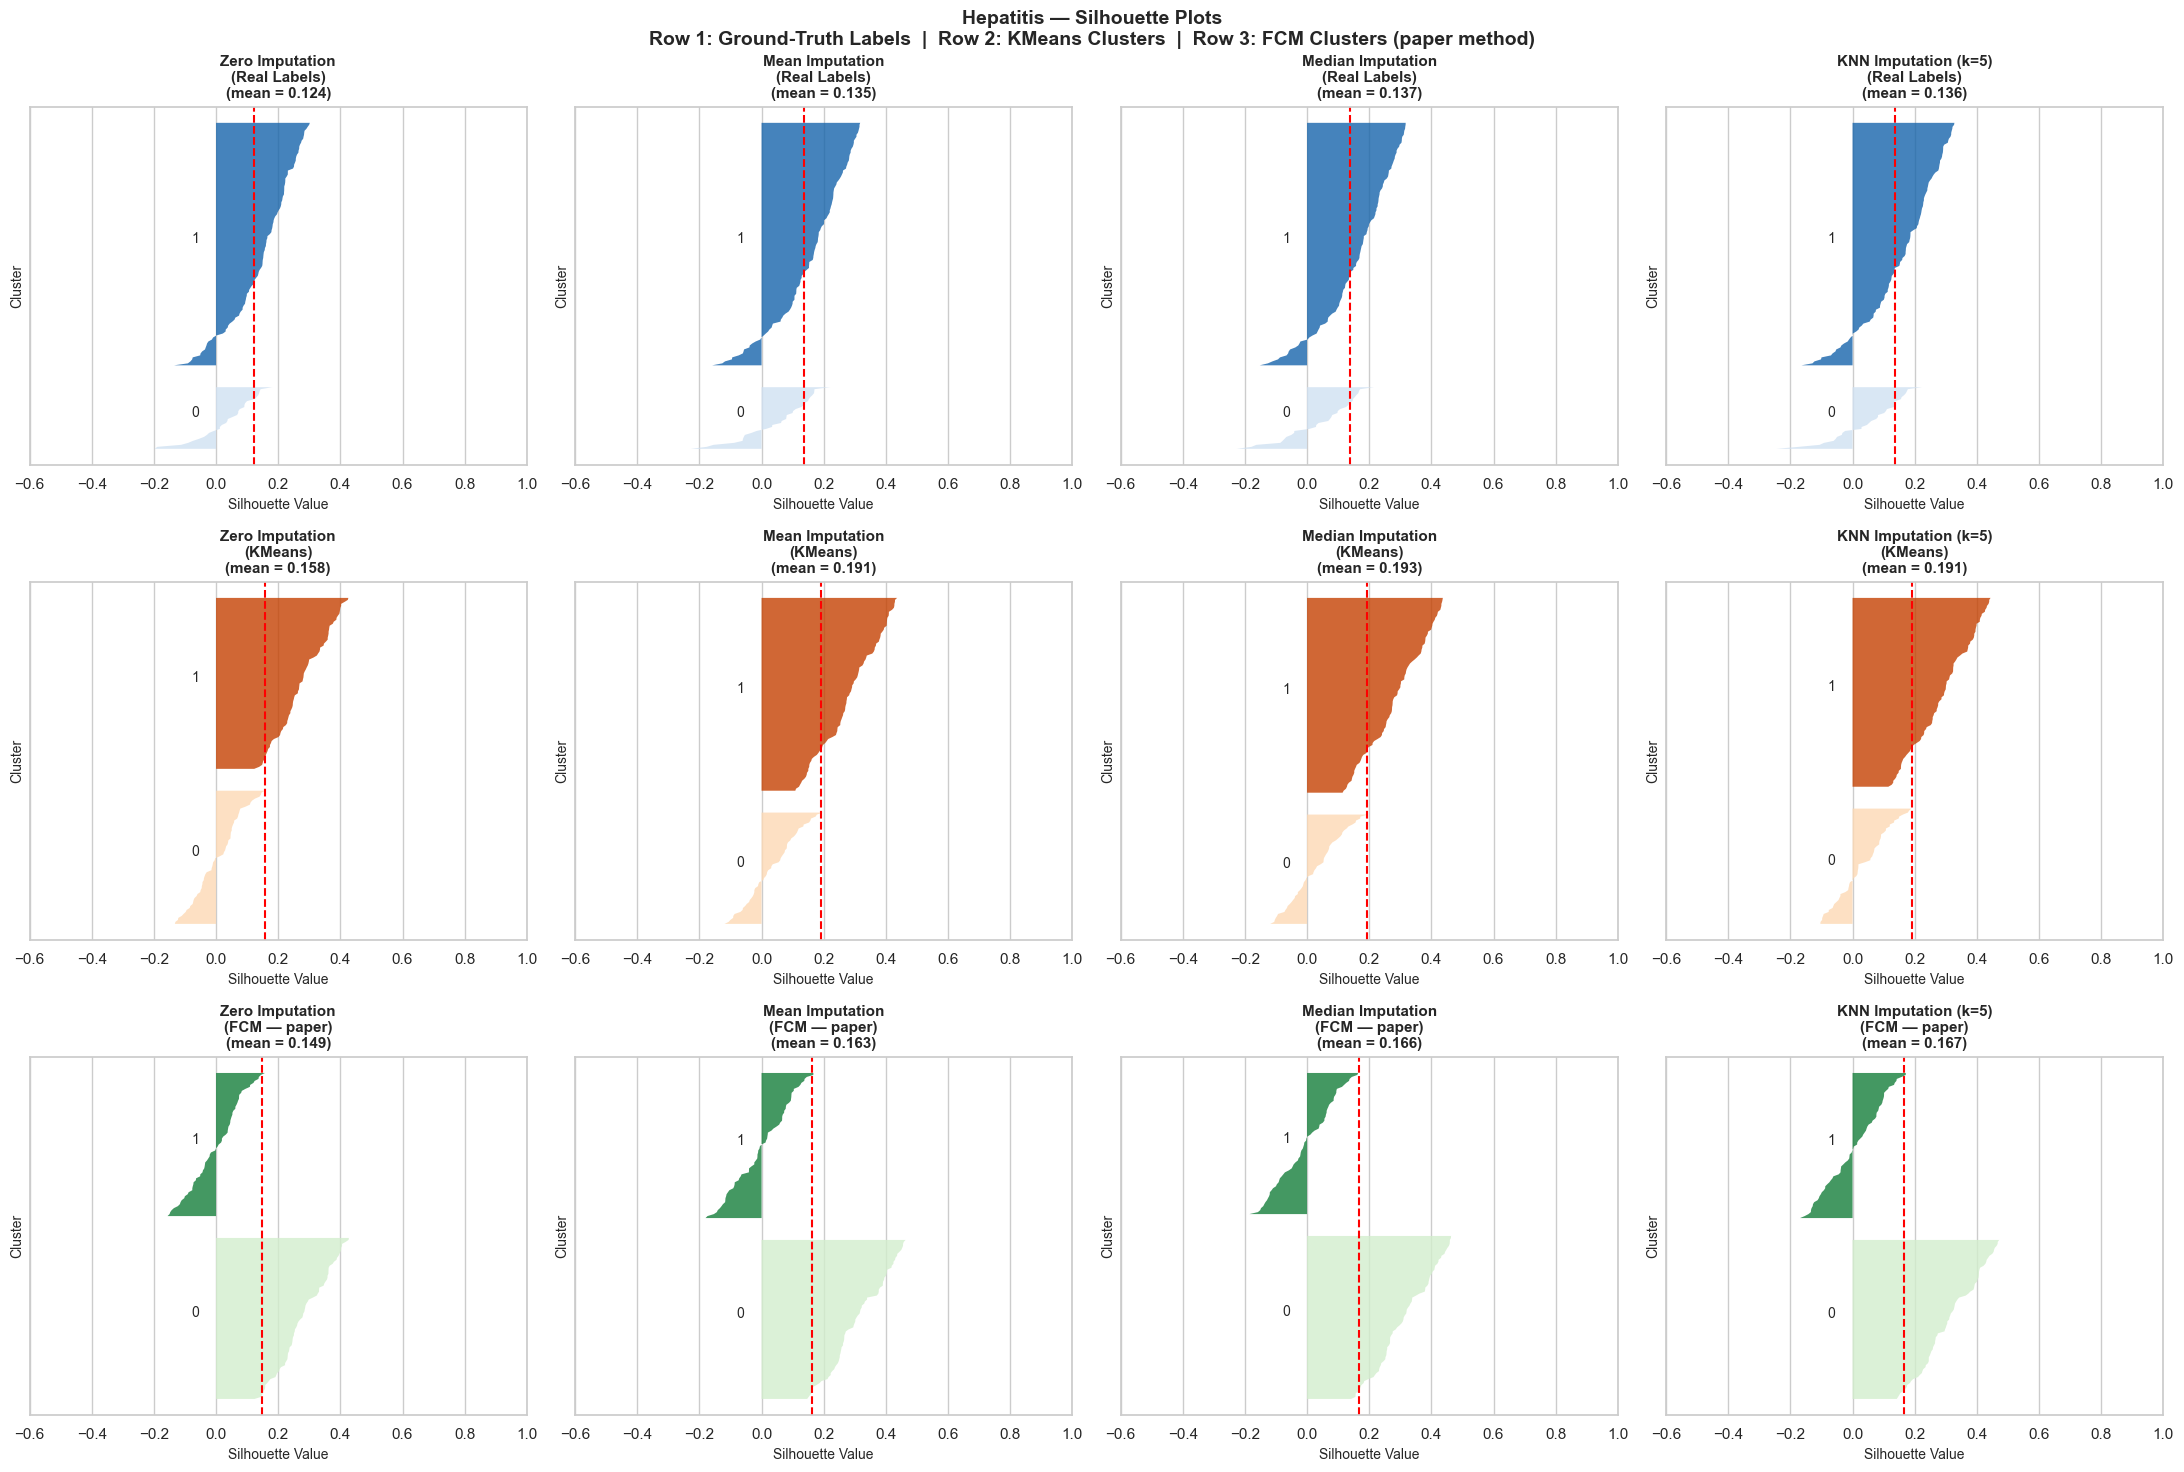


Hepatitis — Silhouette Scores by Strategy:


,Strategy,KMeans Score,FCM Score
0,Zero Imputation,0.1584,0.1491
1,Mean Imputation,0.1909,0.1629
2,Median Imputation,0.1932,0.1661
3,KNN Imputation (k=5),0.1911,0.1670


In [9]:
# ── 5.2  Hepatitis — Silhouette Plots (replicating paper Fig. 3) ──────────────
hep_sil = compute_silhouette_scores(df_hep, 'Class', n_clusters=2)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Hepatitis — Silhouette Plots\n'
             'Row 1: Ground-Truth Labels  |  Row 2: KMeans Clusters  |  Row 3: FCM Clusters (paper method)',
             fontsize=14, fontweight='bold')

for col_idx, (name, data) in enumerate(hep_sil.items()):
    make_silhouette_plot(axes[0][col_idx], data['X_scaled'], data['y_true'],
                         f'{name}\n(Real Labels)', cmap='Blues')
    make_silhouette_plot(axes[1][col_idx], data['X_scaled'], data['labels_km'],
                         f'{name}\n(KMeans)', cmap='Oranges')
    make_silhouette_plot(axes[2][col_idx], data['X_scaled'], data['labels_fcm'],
                         f'{name}\n(FCM — paper)', cmap='Greens')

plt.tight_layout()
plt.show()

print('\nHepatitis — Silhouette Scores by Strategy:')
sil_df_hep = pd.DataFrame([
    {'Strategy': k, 'KMeans Score': v['score_km'], 'FCM Score': v['score_fcm']}
    for k, v in hep_sil.items()
])
display(sil_df_hep.round(4))


### Breast Cancer Silhouette Plots

Same 3-row layout is used for Breast Cancer.
This dataset usually shows stronger separation, so silhouette values are expected to be higher.

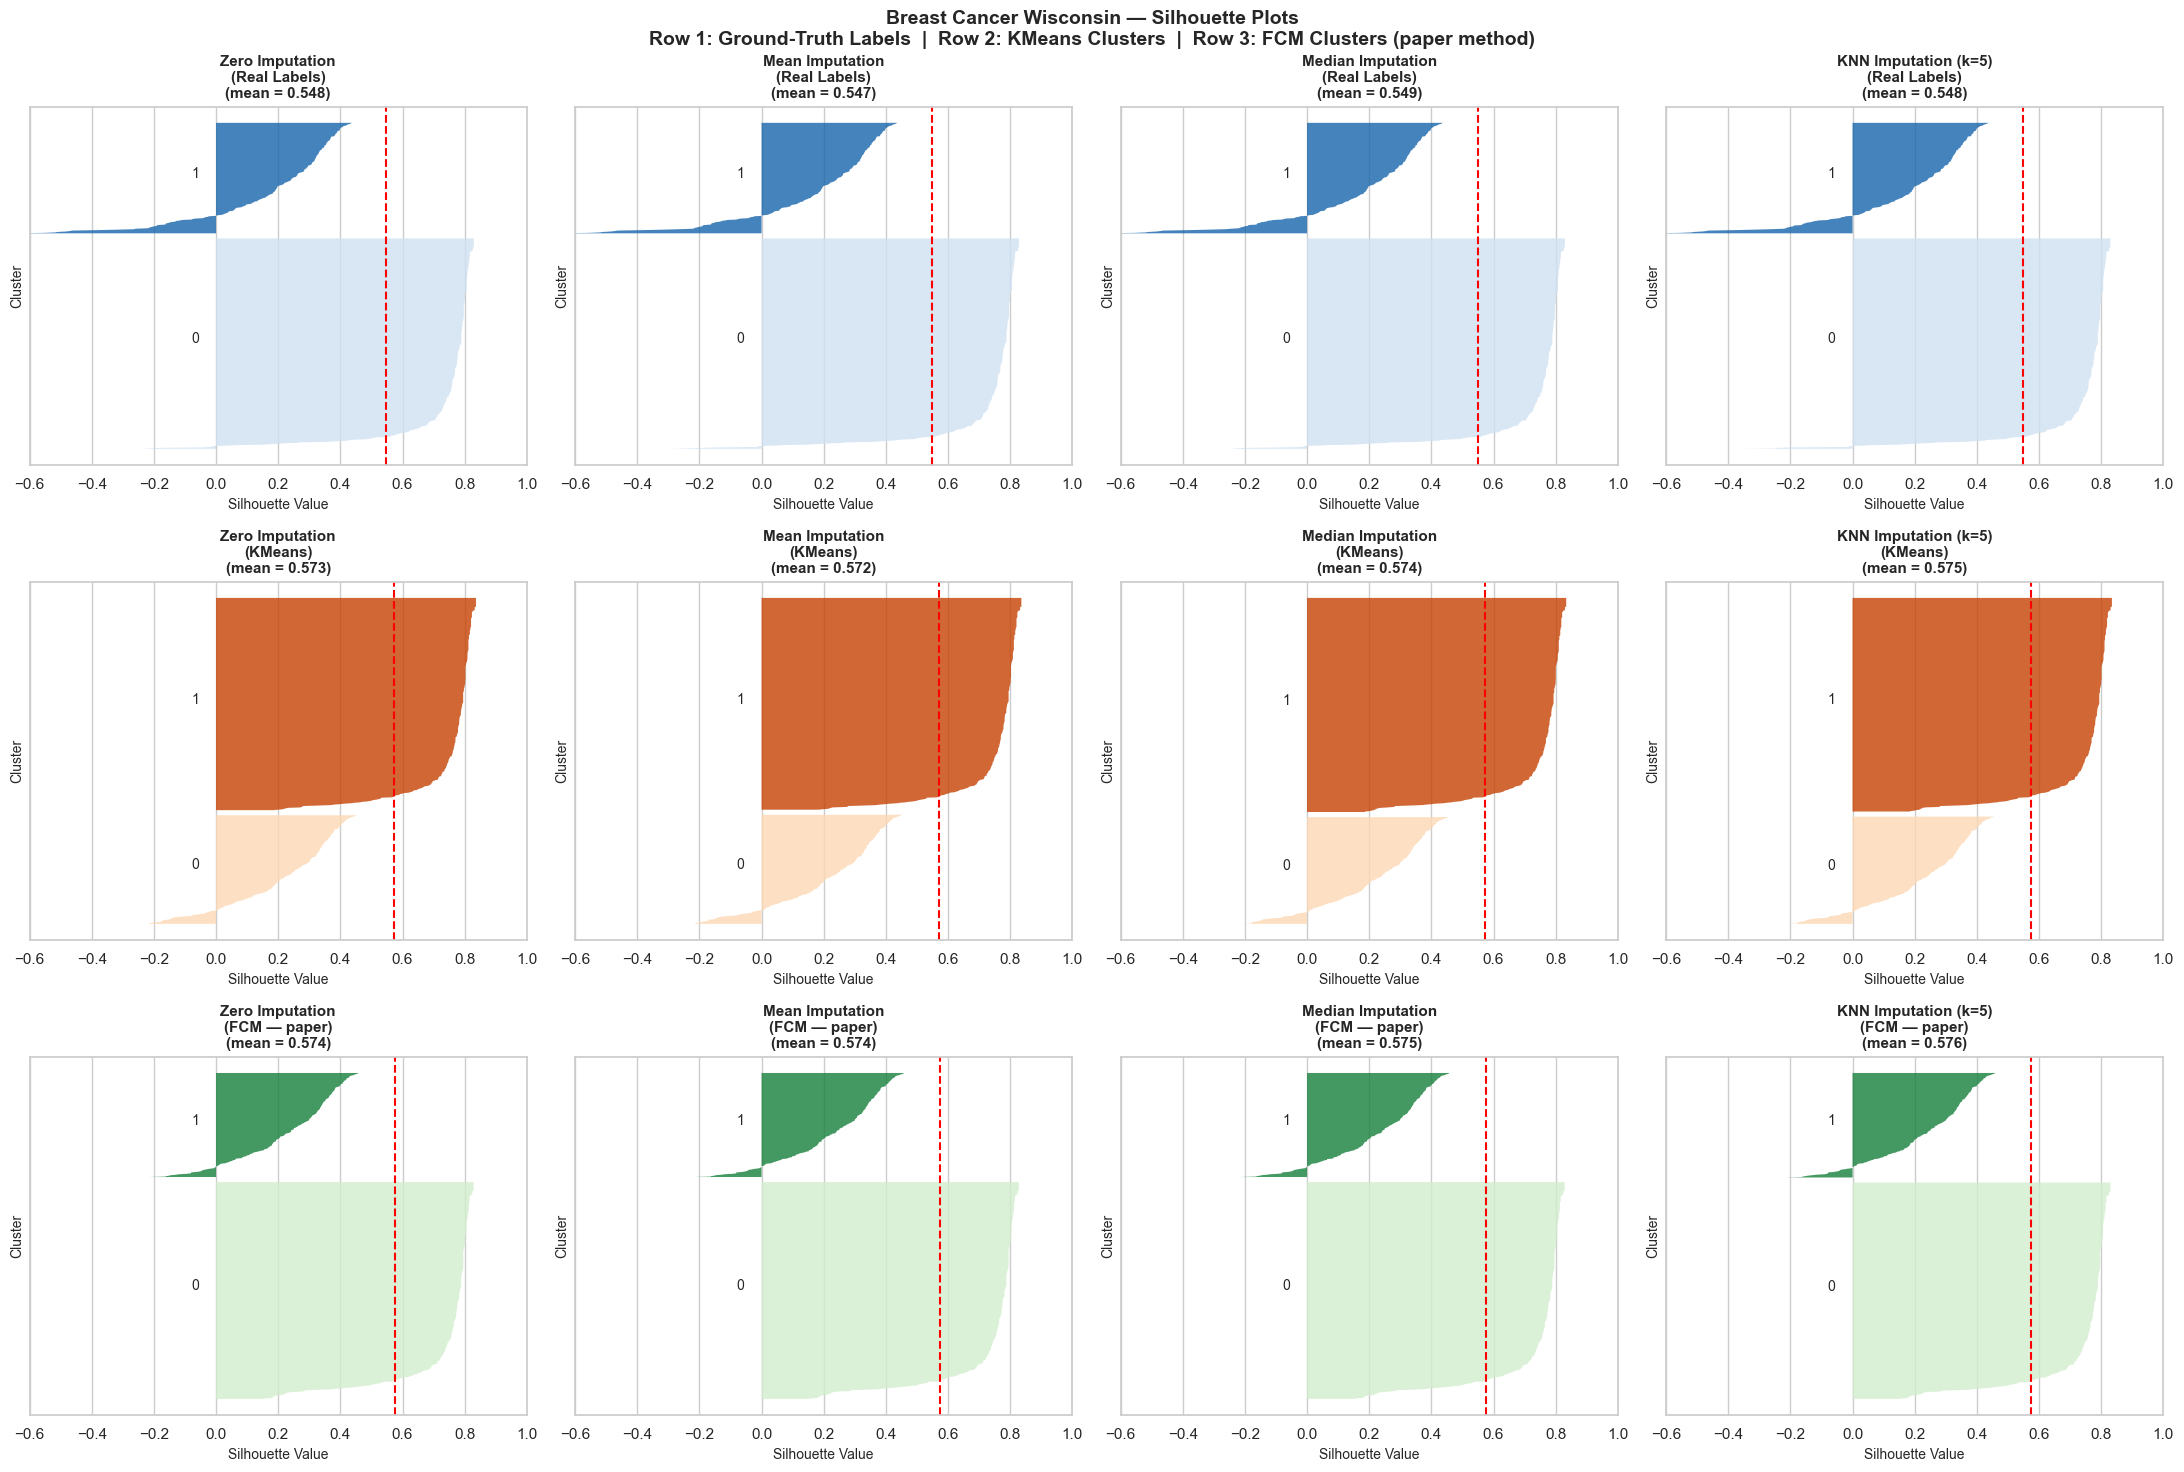


Breast Cancer — Silhouette Scores by Strategy:


,Strategy,KMeans Score,FCM Score
0,Zero Imputation,0.5728,0.5742
1,Mean Imputation,0.5721,0.5737
2,Median Imputation,0.5740,0.5747
3,KNN Imputation (k=5),0.5750,0.5755


In [10]:
# ── 5.3  Breast Cancer — Silhouette Plots (replicating paper Fig. 4) ──────────
bc_sil = compute_silhouette_scores(df_bc, 'Class', n_clusters=2)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Breast Cancer Wisconsin — Silhouette Plots\n'
             'Row 1: Ground-Truth Labels  |  Row 2: KMeans Clusters  |  Row 3: FCM Clusters (paper method)',
             fontsize=14, fontweight='bold')

for col_idx, (name, data) in enumerate(bc_sil.items()):
    make_silhouette_plot(axes[0][col_idx], data['X_scaled'], data['y_true'],
                         f'{name}\n(Real Labels)', cmap='Blues')
    make_silhouette_plot(axes[1][col_idx], data['X_scaled'], data['labels_km'],
                         f'{name}\n(KMeans)', cmap='Oranges')
    make_silhouette_plot(axes[2][col_idx], data['X_scaled'], data['labels_fcm'],
                         f'{name}\n(FCM — paper)', cmap='Greens')

plt.tight_layout()
plt.show()

print('\nBreast Cancer — Silhouette Scores by Strategy:')
sil_df_bc = pd.DataFrame([
    {'Strategy': k, 'KMeans Score': v['score_km'], 'FCM Score': v['score_fcm']}
    for k, v in bc_sil.items()
])
display(sil_df_bc.round(4))


### Silhouette Score Comparison (All Datasets x All Strategies)

This cell compares mean silhouette scores for each imputation strategy across all datasets (KMeans vs FCM).

**Observed results from the comparison:**
- Breast Cancer has the highest silhouette scores in both KMeans and FCM, indicating the clearest cluster structure.
- Pima generally has the lowest scores, showing that class groups overlap more in feature space.
- Differences between imputation strategies are present but relatively small compared with dataset-level differences.
- Zero imputation is not consistently the best strategy across datasets.
- KMeans and FCM show similar ranking trends, but their absolute scores are not identical.

**Interpretation note:** silhouette reflects geometric cluster separation, not direct classification correctness. So accuracy changes can be larger than silhouette changes.

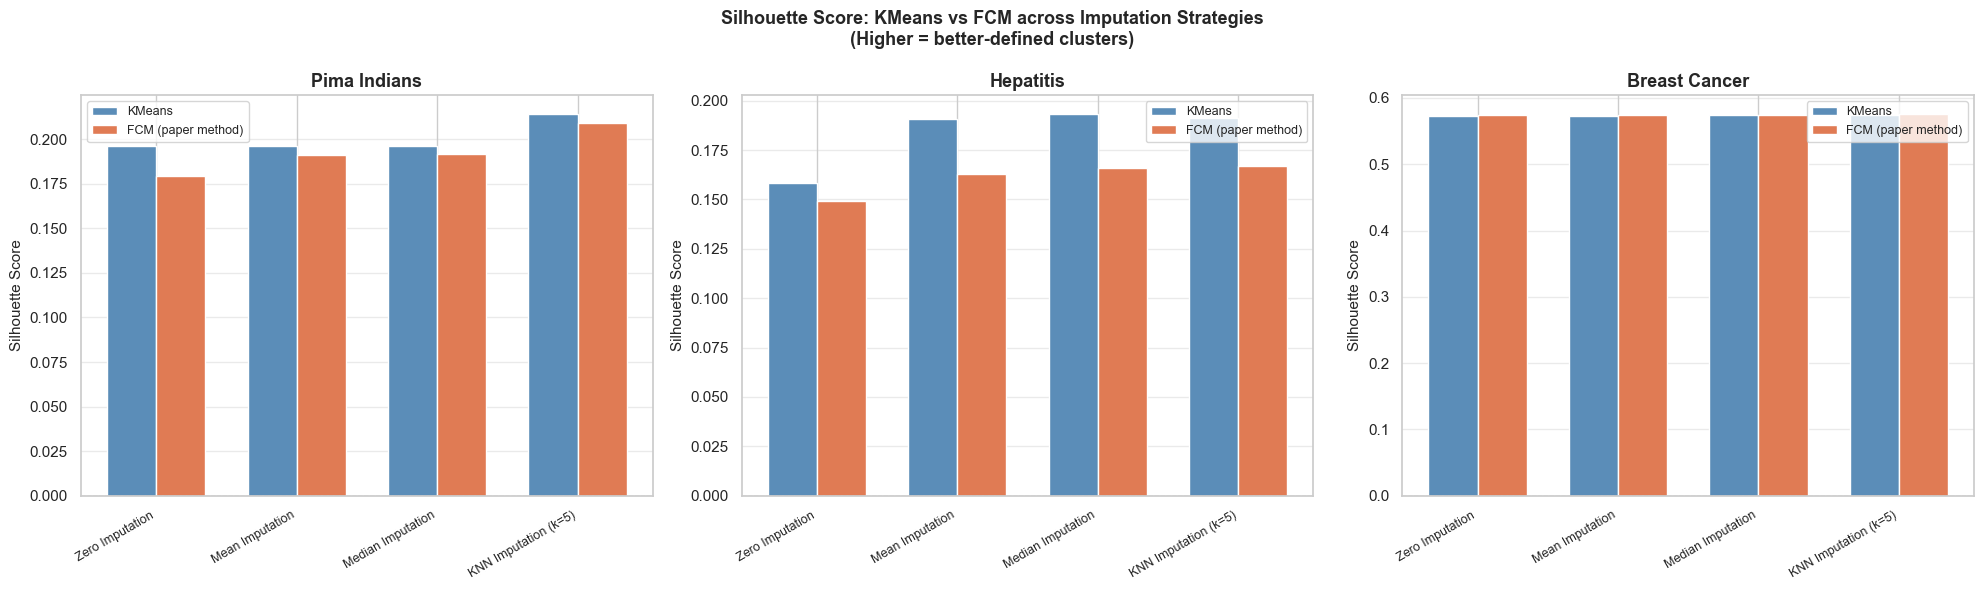


=== Full Silhouette Score Table ===


FCM Score                         KMeans Score  \
Dataset              Breast Cancer Hepatitis Pima Indians Breast Cancer   
Strategy                                                                  
KNN Imputation (k=5)        0.5755    0.1670       0.2094        0.5750   
Mean Imputation             0.5737    0.1629       0.1913        0.5721   
Median Imputation           0.5747    0.1661       0.1918        0.5740   
Zero Imputation             0.5742    0.1491       0.1794        0.5728   

                                             
Dataset              Hepatitis Pima Indians  
Strategy                                     
KNN Imputation (k=5)    0.1911       0.2141  
Mean Imputation         0.1909       0.1965  
Median Imputation       0.1932       0.1963  
Zero Imputation         0.1584       0.1960

In [11]:
# ── 5.4  Silhouette Score Comparison — All Datasets & Strategies ──────────────
sil_records = []
for ds_name, sil_dict in [('Pima Indians', pima_sil),
                            ('Hepatitis',    hep_sil),
                            ('Breast Cancer', bc_sil)]:
    for strat, data in sil_dict.items():
        sil_records.append({'Dataset': ds_name, 'Strategy': strat,
                             'KMeans Score': data['score_km'],
                             'FCM Score':    data['score_fcm']})

sil_all = pd.DataFrame(sil_records)

# ── Grouped bar chart: KMeans vs FCM per strategy per dataset ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, ds in zip(axes, ['Pima Indians', 'Hepatitis', 'Breast Cancer']):
    sub = sil_all[sil_all['Dataset'] == ds].set_index('Strategy')
    x   = np.arange(len(sub))
    w   = 0.35
    ax.bar(x - w/2, sub['KMeans Score'], width=w, label='KMeans',
           color='#5b8db8', edgecolor='white')
    ax.bar(x + w/2, sub['FCM Score'],    width=w, label='FCM (paper method)',
           color='#e07b54', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(ds, fontsize=13, fontweight='bold')
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Silhouette Score: KMeans vs FCM across Imputation Strategies\n'
             '(Higher = better-defined clusters)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Full Silhouette Score Table ===')
display(sil_all.pivot_table(index='Strategy', columns='Dataset',
                             values=['KMeans Score', 'FCM Score']).round(4))


---
## 6. Master Results Table

This section merges classification accuracy and silhouette scores into one summary view.

### Master Results Table

Rows: imputation strategies  
Columns: dataset-specific accuracy and silhouette metrics

This creates a single comparison table for all core findings.

In [13]:
# ── Build a clean summary table ───────────────────────────────────────────────
acc_pivot = all_results.pivot_table(
    index='Strategy', columns='Dataset', values='Our Acc (%)')

sil_km_pivot  = sil_all.pivot_table(index='Strategy', columns='Dataset', values='KMeans Score')
sil_fcm_pivot = sil_all.pivot_table(index='Strategy', columns='Dataset', values='FCM Score')

acc_pivot.columns     = [f'{c} Acc (%)'    for c in acc_pivot.columns]
sil_km_pivot.columns  = [f'{c} KMeans Sil.' for c in sil_km_pivot.columns]
sil_fcm_pivot.columns = [f'{c} FCM Sil.'    for c in sil_fcm_pivot.columns]

master = acc_pivot.join(sil_km_pivot, how='left').join(sil_fcm_pivot, how='left')
master = master.round(3)

print('Master Results Table — Accuracy (%) · KMeans Silhouette · FCM Silhouette')
display(master)


Master Results Table — Accuracy (%) · KMeans Silhouette · FCM Silhouette


,Breast Cancer Acc (%),Hepatitis Acc (%),Pima Acc (%),Breast Cancer KMeans Sil.,Hepatitis KMeans Sil.,Pima Indians KMeans Sil.,Breast Cancer FCM Sil.,Hepatitis FCM Sil.,Pima Indians FCM Sil.
Strategy,,,,,,,,,
KNN Imputation (k=5),95.238,89.362,73.593,0.575,0.191,0.214,0.576,0.167,0.209
Mean Imputation,95.238,87.234,74.026,0.572,0.191,0.197,0.574,0.163,0.191
Median Imputation,95.238,87.234,74.459,0.574,0.193,0.196,0.575,0.166,0.192
Random Imputation,95.238,82.979,73.160,NaN,NaN,NaN,NaN,NaN,NaN
WDS (Drop NaN),95.610,83.333,77.966,NaN,NaN,NaN,NaN,NaN,NaN
Zero Imputation,95.238,85.106,71.429,0.573,0.158,0.196,0.574,0.149,0.179


---
## 7. Final Discussion

### Summary
- The paper's "zero is best" claim is not consistently supported under a leakage-safe supervised evaluation.
- Mean/median are simple baselines; KNN imputation often preserves structure better.
- WDS can improve cleanliness but may discard too much data.

### Practical takeaways
1. Use a supervised model for classification accuracy.
2. Always scale features for distance-based methods.
3. Fit imputation on train data only, then transform test data.
4. Use silhouette as a complementary structural metric, not a replacement for classification metrics.